
# What do wrong human labels do to the crank?

**RLHF goes both ways.** The RUSH crank optimizes a policy document against SME labels: a judge
panel reads the policy and labels images, panel-vs-SME misalignment picks anchor points, a drafter
edits the policy, and a gate accepts/rejects the edit by scoring the panel against human labels on
a test partition. The human labels are the reward signal — so a **mislabeled item becomes an
anchor** and can steer the policy toward the wrong boundary. Empirically our labels are imperfect:
of the LLM-vs-SME disagreements sent to re-adjudication, **~33% were overturned in favor of the
LLM** (~44% in the sensitive-content area).

This notebook runs the [labelsim](../labelsim) package — the crank abstracted into a 2D geometry
where ground truth is knowable. Two questions:

1. **Divergence** — how far does label noise bend the learned policy away from the one a
   clean-labeled *twin universe* (common random numbers) would have learned — and how far does
   *theory say* it should bend it?
2. **Convergence of the weighting methodology** — does Bayesian per-label confidence
   (non-perfect prior at N=1) de-weighting converge back to truth, alone and combined with
   budgeted SME re-adjudication?

### Reading guide

| § | What | Why it's here |
|---|---|---|
| 0 | **Simulation input parameters** | every knob, with its RUSH analogue |
| 1 | The two worlds (genai / mnist) | where the mislabels live |
| 2 | **Theory: the divergence we expect** | closed-form noisy-Bayes boundary shift; the collapse threshold; why two-sided noise cancels |
| 3 | **Gradient descent on the wrong landscape** | policy space as a 2D plane: loss contours + 3D surface, twin trajectories |
| 4 | Anatomy of one run | the trajectories behind every aggregate |
| 5 | **Measured vs theoretical divergence** | the sim against the §2 curves, gate on vs off |
| 6–10 | Suites S1–S5 | dose-response, mitigation, parallel universes, gate corruption, sampling |
| 11 | **S6 — the breakdown map** | 10/20/30/50% wrong labels: where the system breaks, and what the anchors look like |
| 12 | **S7 — do starting conditions matter?** | same world, only v0 varies (the Lyapunov-lite probe) |
| 13 | Takeaways + how we test this on the real crank | the transfer plan |


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # sim/label-noise
warnings.filterwarnings("ignore")

import dataclasses
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from labelsim import *
from labelsim.engine import build_world, clean_labels, divergence_series, point_influence
from labelsim.experiments import (base_config, suite_noise, s1_dose_response,
                                  s2_mitigation, s4_test_corruption, s5_sampling,
                                  s6_breakdown, s7_init_sensitivity)
from labelsim.judges import DEFAULT_SIGMAS
from labelsim.policy import LogisticPolicy, fit_oracle
from labelsim.metrics import macro_f1, mean_ci

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False})
C0, C1, CN, CC, CO = "#3b6fb6", "#d1495b", "#222222", "#7aa874", "#999999"
SEED = 13
print("labelsim", __import__("labelsim").__version__)

labelsim 0.1.0


## 0 · Simulation input parameters

Every run in this notebook starts from this base configuration (overrides are stated per
experiment). The table is generated from the live dataclasses so it cannot drift from the code.


In [2]:
CFG = base_config("genai", seed=SEED)
ANALOGUE = {
    "dataset": "which world: genai (binary) / mnist (10-class LDA plane)",
    "seed": "keys every random stream (data, judges, noise, queues)",
    "cycles": "crank cycles k (label -> anchor -> draft -> gate)",
    "train_batch": "images labeled per cycle (batch_n)",
    "test_n": "gate partition size (test_n)",
    "resample_test": "fixed yardstick vs per-cycle resample (r67 option)",
    "n_anchors": "anchors fed to the drafter (max_anchors)",
    "anchor_strategy": "stack_rank / pps / random anchor selection",
    "lr": "drafter step size (edit aggressiveness)",
    "clip": "step-norm clip = the 1-5-discrete-edits rule",
    "gate": "accept candidate only if human-label macro-F1 does not drop",
    "gate_eps": "gate margin epsilon",
    "weighting": "anchor weight from label confidence: off/deweight/deweight_hard/upweight",
    "upweight_amp": "hyper-focus amplification in the upweight universe",
    "noise": "label corruption model (see below)",
    "conf": "Bayesian label-confidence constants (see below)",
    "readj": "budgeted SME re-adjudication (see below)",
    "panel": "judge panel composition",
    "v0_rotate_deg": "v0 misspecification: oracle boundary rotated this much",
    "v0_jitter": "mnist v0 prototype jitter (data std units)",
    "dataset_kw": "world-size overrides",
}
rows = ["| parameter | value | RUSH analogue |", "|---|---|---|"]
for f in dataclasses.fields(CFG):
    v = getattr(CFG, f.name)
    if dataclasses.is_dataclass(v):
        v = ", ".join(f"{sf.name}={getattr(v, sf.name)}" for sf in dataclasses.fields(v))
    rows.append(f"| `{f.name}` | `{v}` | {ANALOGUE.get(f.name, '')} |")
rows.append(f"| `panel sigmas` | `{DEFAULT_SIGMAS}` | per-judge perception noise = (inverse) model capacity |")
display(Markdown("\n".join(rows)))
display(Markdown(
    "**Noise fields**: `model` uniform/boundary/pair; `rate` = fraction of ALL eligible labels "
    "flipped; `tau` = boundary concentration (flip prob ~ exp(-margin/tau)); `target` "
    "train/test/both (both = the same SMEs label everything); `flip_from` = one-way flips from "
    "that true class only (directional adult-vs-racy confusion), count still rate x all labels, "
    "capped at the class pool.\n\n"
    "**Confidence fields**: prior `c0=0.9` at N=1 (a human label is never certain); assumed panel "
    "likelihoods `p_catch=0.75` (panel disagrees | label wrong), `p_false=0.25` (panel disagrees "
    "| label right), scaled by consensus share; adjudicated labels pin to 0.99.\n\n"
    "**Re-adjudication fields**: queue strategy stack_rank / PPS (probability-proportional-to-size sampling) / random over accumulated "
    "disagreement mass; `budget`/`test_budget` reviews per cycle; `q_sme=0.95` = P(full-attention "
    "review returns truth)."))

| parameter | value | RUSH analogue |
|---|---|---|
| `dataset` | `genai` | which world: genai (binary) / mnist (10-class LDA plane) |
| `seed` | `13` | keys every random stream (data, judges, noise, queues) |
| `cycles` | `30` | crank cycles k (label -> anchor -> draft -> gate) |
| `train_batch` | `40` | images labeled per cycle (batch_n) |
| `test_n` | `100` | gate partition size (test_n) |
| `resample_test` | `False` | fixed yardstick vs per-cycle resample (r67 option) |
| `n_anchors` | `10` | anchors fed to the drafter (max_anchors) |
| `anchor_strategy` | `stack_rank` | stack_rank / pps / random anchor selection |
| `lr` | `0.4` | drafter step size (edit aggressiveness) |
| `clip` | `0.5` | step-norm clip = the 1-5-discrete-edits rule |
| `gate` | `on` | accept candidate only if human-label macro-F1 does not drop |
| `gate_eps` | `0.0` | gate margin epsilon |
| `weighting` | `off` | anchor weight from label confidence: off/deweight/deweight_hard/upweight |
| `upweight_amp` | `1.0` | hyper-focus amplification in the upweight universe |
| `noise` | `model=boundary, rate=0.15, tau=0.25, target=both, flip_from=None, pairs=((4, 9), (3, 5), (7, 1), (3, 8))` | label corruption model (see below) |
| `conf` | `c0=0.9, p_catch=0.75, p_false=0.25, adjudicated_conf=0.99` | Bayesian label-confidence constants (see below) |
| `readj` | `strategy=off, budget=5, q_sme=0.95, include_test=False, test_budget=5` | budgeted SME re-adjudication (see below) |
| `panel` | `noncompliant=False, constant_class=0, exclude_noncompliant=False` | judge panel composition |
| `v0_rotate_deg` | `(30.0, 60.0)` | v0 misspecification: oracle boundary rotated this much |
| `v0_jitter` | `0.8` | mnist v0 prototype jitter (data std units) |
| `v0_seed` | `None` |  |
| `dataset_kw` | `{}` | world-size overrides |
| `panel sigmas` | `(0.15, 0.25, 0.35, 0.5, 0.7)` | per-judge perception noise = (inverse) model capacity |

**Noise fields**: `model` uniform/boundary/pair; `rate` = fraction of ALL eligible labels flipped; `tau` = boundary concentration (flip prob ~ exp(-margin/tau)); `target` train/test/both (both = the same SMEs label everything); `flip_from` = one-way flips from that true class only (directional adult-vs-racy confusion), count still rate x all labels, capped at the class pool.

**Confidence fields**: prior `c0=0.9` at N=1 (a human label is never certain); assumed panel likelihoods `p_catch=0.75` (panel disagrees | label wrong), `p_false=0.25` (panel disagrees | label right), scaled by consensus share; adjudicated labels pin to 0.99.

**Re-adjudication fields**: queue strategy stack_rank / PPS (probability-proportional-to-size sampling) / random over accumulated disagreement mass; `budget`/`test_budget` reviews per cycle; `q_sme=0.95` = P(full-attention review returns truth).

## 1 · The worlds

Left: the genai binary world — each class has an easy mass and a contested ridge where the classes
genuinely interleave. Right: real MNIST in the Fisher-LDA plane. **Red rings mark injected
mislabels** (boundary-concentrated, flip target = the confusable runner-up class): the mislabels
sit exactly where the hard, legitimately-arguable cases live — a mislabeled easy case (the puppy)
never occurs under the boundary model. (This figure's draw: rate 0.15, boundary model; the genai
panel uses the dataset-default ONE-WAY flips — gen_ai items labeled not_gen_ai — while mnist flips
two-sided to the runner-up class.)


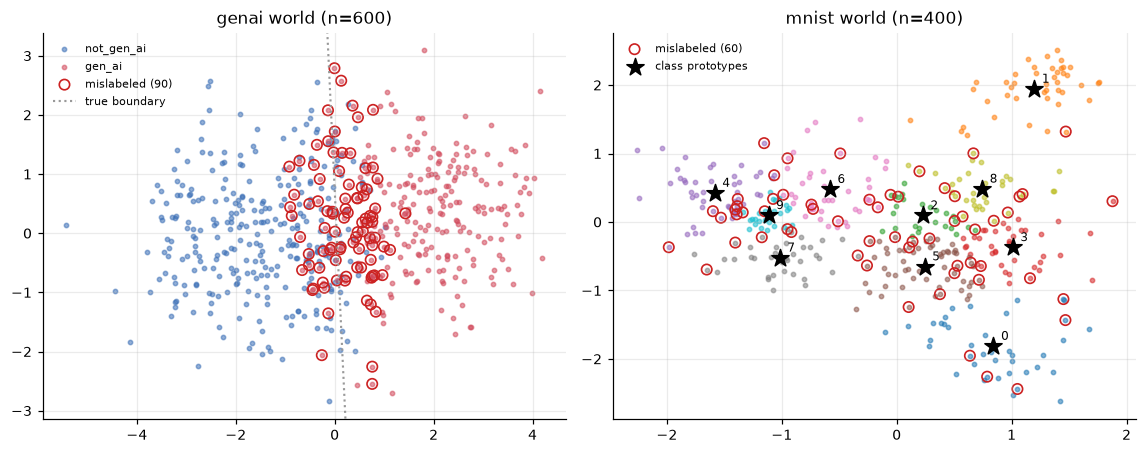

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, name in zip(axes, ("genai", "mnist")):
    cfg = base_config(name, seed=SEED, noise=suite_noise(name, rate=0.15))
    ds, (y_h, flipped) = build_world(cfg)
    cmap = plt.get_cmap("tab10")
    for c in range(ds.n_classes):
        m = ds.y == c
        ax.scatter(ds.X[m, 0], ds.X[m, 1], s=8, alpha=0.55,
                   color=(C0 if c == 0 else C1) if ds.n_classes == 2 else cmap(c),
                   label=(ds.class_names[c] if ds.n_classes == 2 else None))
    ax.scatter(ds.X[flipped, 0], ds.X[flipped, 1], s=46, facecolors="none",
               edgecolors="#c22", linewidths=1.1, label=f"mislabeled ({flipped.sum()})")
    oracle = fit_oracle(ds)
    if ds.n_classes == 2:
        w, b = oracle.w, oracle.b
        x0_, x1_ = ax.get_xlim(); y0_, y1_ = ax.get_ylim()
        if abs(w[1]) >= abs(w[0]):     # plot along the better-conditioned axis
            xs = np.linspace(x0_, x1_, 50)
            ax.plot(xs, -(w[0] * xs + b) / w[1], ":", color=CO, lw=1.4, label="true boundary")
        else:
            ys = np.linspace(y0_, y1_, 50)
            ax.plot(-(w[1] * ys + b) / w[0], ys, ":", color=CO, lw=1.4, label="true boundary")
        ax.set_xlim(x0_, x1_); ax.set_ylim(y0_, y1_)
    else:
        ax.scatter(oracle.protos[:, 0], oracle.protos[:, 1], marker="*", s=140,
                   color="k", zorder=5, label="class prototypes")
        for c, p in enumerate(oracle.protos):
            ax.annotate(str(c), p, textcoords="offset points", xytext=(5, 4), fontsize=8)
    ax.set_title(f"{name} world (n={ds.n})")
    ax.legend(loc="upper left", fontsize=7.5)
plt.tight_layout()


## 2 · Theory: the divergence we should expect

Write $\eta(x) = P(y{=}1 \mid x)$ for the true class-1 posterior, and let $m$ be the signed
distance from the true boundary ($m>0$ on the class-1 side). Locally, $\eta(m) = \sigma(\beta m)$
with slope $\beta$ (we estimate $\hat\beta$ from the world below).

**One-way noise** (the adult-labeled-racy failure mode): each true class-1 label is flipped to 0
with probability $\rho_1$. With our rate convention (`rate` = fraction of *all* labels, balanced
classes) $\rho_1 = 2\cdot\text{rate}$. The observed posterior becomes

$$P(\tilde y = 1 \mid x) \;=\; (1-\rho_1)\,\eta(x).$$

An accuracy-optimal learner of the noisy labels (the Bayes rule for $\tilde y$) puts its boundary where $P(\tilde y=1|x) = \tfrac12$, i.e. at

$$\eta(x) \;=\; c^*(\rho_1) \;=\; \frac{1}{2\,(1-\rho_1)}
\qquad\Longrightarrow\qquad
\boxed{\;\Delta_{\text{theory}}(\rho_1) \;=\; \frac{\operatorname{logit} c^*(\rho_1)}{\beta}\;}$$

— the **theoretical divergence**: how far the noisy-optimal boundary sits from the true one,
measured along the boundary normal. Two regimes fall straight out of the formula:

- $c^*(\rho_1) \ge 1$ when $\rho_1 \ge \tfrac12$ (**rate ≥ 0.25**): no point qualifies as class 1
  any more — the noisy-optimal classifier **collapses to all-class-0**. $\Delta \to \infty$.
- **Two-sided symmetric noise** at rate $\rho$: $P(\tilde y=1|x) = \eta(1-\rho) + (1-\eta)\rho$,
  which still crosses $\tfrac12$ exactly where $\eta = \tfrac12$. **Zero asymptotic boundary
  shift** — symmetric flips only add variance. This is why S1's two-sided cells barely move and
  the one-way cells crater.

Two caveats that make the sim interesting rather than redundant:

1. The crank does not fit the noisy labels by MLE — it takes clipped anchor steps and a **gate**
   only accepts steps that don't hurt *macro-F1 on the (noisy) test labels*. Macro-F1 hates the
   all-0 collapse (class-1 F1 goes to zero), so the gate should act as a brake well before the
   accuracy-optimal collapse. We compute the **noisy-metric optimum** (the macro-F1-optimal
   threshold under noisy labels) numerically as the second theory curve.
2. Boundary-concentrated noise makes $\rho_1$ a function of $m$; the same fixed-point equation is
   solved numerically. (This section uses the uniform one-way model, where the closed form is
   exact.)

The code cell verifies the derivation *inside the world*: the binned empirical
$P(\tilde y{=}1 \mid m)$ lands on the scaled curve $(1-\rho_1)\,\hat\eta(m)$, and the crossing
points are the predicted thresholds.


beta_hat = 2.79   true-boundary crossing z = +0.001
dots = binned empirical noisy labels; they land on the scaled curve as derived


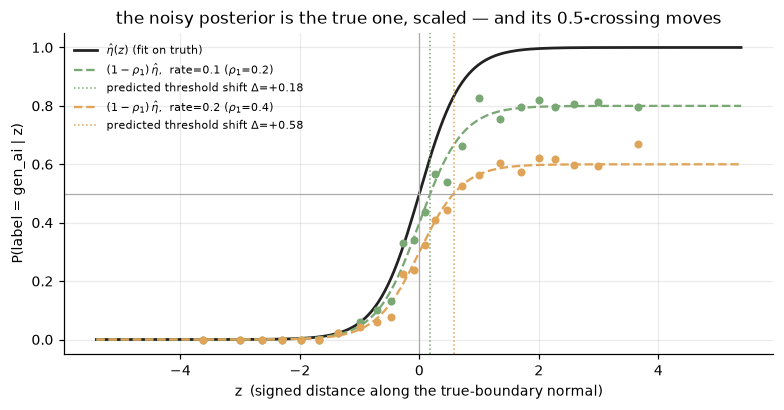

In [4]:
# a big same-distribution sample for population-level estimates
BIG = make_genai(n=4000, seed=SEED)
ORC = fit_oracle(BIG)
N_HAT = ORC.w / np.linalg.norm(ORC.w)          # boundary normal, points to class 1
X0 = BIG.X.mean(axis=0)
def z_of(X):                                    # signed coordinate along the normal
    return (X - X0) @ N_HAT

# 1D logistic MLE of y on z -> eta_hat(z) = sigma(beta (z - z0))
z = z_of(BIG.X); yb = BIG.y.astype(float)
a, c = 1.0, 0.0
for _ in range(4000):
    p = 1/(1 + np.exp(-(a*z + c)))
    g = p - yb
    a -= 0.05 * (g @ z) / len(z); c -= 0.05 * g.mean()
BETA_HAT, Z_BAYES = a, -c/a                     # eta = 0.5 at z = Z_BAYES
def eta_hat(zz): return 1/(1 + np.exp(-(BETA_HAT*(zz - Z_BAYES))))
print(f"beta_hat = {BETA_HAT:.2f}   true-boundary crossing z = {Z_BAYES:+.3f}")

def logit(p): return np.log(p/(1-p))
def delta_theory(rate):
    rho1 = 2*rate
    cstar = 0.5/(1-rho1) if rho1 < 0.5 else np.nan
    return logit(cstar)/BETA_HAT if (cstar and cstar < 1) else np.nan

fig, ax = plt.subplots(figsize=(7.2, 3.8))
zz = np.linspace(z.min(), z.max(), 200)
ax.plot(zz, eta_hat(zz), color=CN, lw=1.8, label=r"$\hat\eta(z)$ (fit on truth)")
for rate, col in ((0.1, "#7aa874"), (0.2, "#e0a458")):
    rho1 = 2*rate
    y_noisy, _ = apply_noise(BIG, NoiseConfig(model="uniform", rate=rate, flip_from=1),
                             seed=SEED, oracle=ORC)
    bins = np.quantile(z, np.linspace(0, 1, 25))
    mids, frac = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() > 20:
            mids.append(z[m].mean()); frac.append(y_noisy[m].mean())
    ax.plot(zz, (1-rho1)*eta_hat(zz), "--", color=col, lw=1.5,
            label=rf"$(1-\rho_1)\,\hat\eta$,  rate={rate} ($\rho_1$={rho1:.1f})")
    ax.scatter(mids, frac, s=18, color=col, zorder=5)
    d = delta_theory(rate)
    ax.axvline(Z_BAYES + d, color=col, lw=1.0, ls=":",
               label=rf"predicted threshold shift $\Delta$={d:+.2f}")
ax.axhline(0.5, color="#aaa", lw=0.8)
ax.axvline(Z_BAYES, color="#aaa", lw=0.8)
ax.set(xlabel="z  (signed distance along the true-boundary normal)",
       ylabel="P(label = gen_ai | z)",
       title="the noisy posterior is the true one, scaled — and its 0.5-crossing moves")
ax.legend(fontsize=7.5, loc="upper left")
plt.tight_layout()
print("dots = binned empirical noisy labels; they land on the scaled curve as derived")


## 3 · Gradient descent on the wrong landscape

The policy is a point in a 2D parameter plane: a boundary is $(\varphi, d)$ — its normal's angle
and its offset ($\{x : \hat n(\varphi)\cdot x = d\}$, class 1 on the $+\hat n$ side). Every crank
cycle is a clipped gradient step in this plane. The loss surface it *descends* is measured against
the **noisy human labels**; the surface we *care about* is measured against **truth**. Label noise
moves the minimum of the first surface away from the minimum of the second — the gap between the
two minima is §2's divergence expressed in the gate's own metric (these surfaces are macro-F1, so
the gap matches the noisy-metric optimum, which shifts less than the accuracy-Bayes threshold).

Below: 20% one-way uniform noise ($\rho_1 = 0.4$, just under the collapse threshold, so both
minima sit inside the window). Contours = $1-$macro-F1. Trajectories: the gated run, the ungated
run, and the clean twin, all from the shared v0. Past rate 0.25 the noisy surface's pull heads to
infinity (the §2 collapse) and ungated trajectories leave any finite window — §5 sweeps the full
range and counts those collapses; this figure stays in the readable regime.


minima: noisy surface (phi=+0.08, d=+0.69)  vs  true surface (phi=+0.15, d=+0.29)  -> offset gap +0.40 = the noisy-METRIC optimum shift (macro-F1 surfaces; the accuracy-Bayes shift of the theory section is larger)


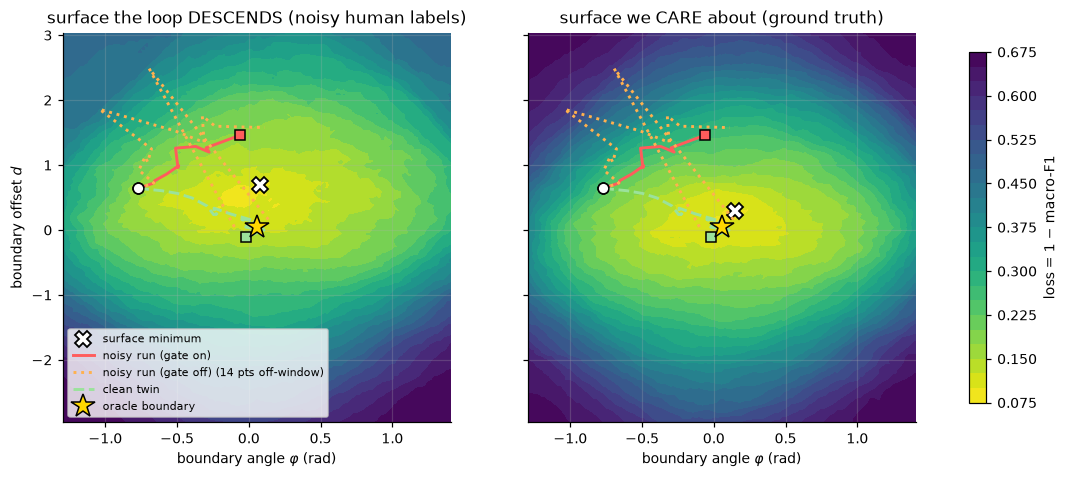

In [5]:
RATE_LAND = 0.2   # rho_1 = 0.4: strong pull, still pre-collapse (readable window)
cfg_land = base_config("genai", seed=SEED, cycles=40,
                       noise=NoiseConfig(model="uniform", rate=RATE_LAND, flip_from=1,
                                         target="both"))
ds_l, labels_l = build_world(cfg_land)
res_gate = run_crank(cfg_land, ds=ds_l, labels=labels_l)
res_nogate = run_crank(dataclasses.replace(cfg_land, gate="off"), ds=ds_l, labels=labels_l)
res_clean = run_crank(cfg_land, ds=ds_l, labels=clean_labels(ds_l))
orc_l = res_gate["oracle"]

def to_phi_d(pol):
    nw = np.linalg.norm(pol.w)
    return np.arctan2(pol.w[1], pol.w[0]), -pol.b / nw

def traj(res):
    pts = np.array([to_phi_d(p) for p in res["snapshots"]])
    return pts[:, 0], pts[:, 1]

phi_o, d_o = to_phi_d(orc_l)
phis = phi_o + np.linspace(-1.35, 1.35, 121)
offs = d_o + np.linspace(-3.0, 3.0, 121)

def loss_grid(labels):
    L = np.empty((len(phis), len(offs)))
    y = labels
    for i, phi in enumerate(phis):
        proj = ds_l.X @ np.array([np.cos(phi), np.sin(phi)])
        pred = proj[:, None] > offs[None, :]          # (n, J)
        tp1 = ((pred) & (y[:, None] == 1)).sum(0); fp1 = ((pred) & (y[:, None] == 0)).sum(0)
        fn1 = ((~pred) & (y[:, None] == 1)).sum(0)
        tp0 = ((~pred) & (y[:, None] == 0)).sum(0); fp0 = fn1; fn0 = fp1
        f1_1 = np.where(2*tp1+fp1+fn1 > 0, 2*tp1/np.maximum(2*tp1+fp1+fn1, 1), 0.0)
        f1_0 = np.where(2*tp0+fp0+fn0 > 0, 2*tp0/np.maximum(2*tp0+fp0+fn0, 1), 0.0)
        L[i] = 1 - 0.5*(f1_0 + f1_1)
    return L

L_noisy = loss_grid(labels_l[0])   # the surface the loop descends
L_true = loss_grid(ds_l.y)         # the surface we care about
PHI, D = np.meshgrid(phis, offs, indexing="ij")

def in_window(tp, td):
    # Trajectory points inside the plotted grid. The (phi,d) parameterization
    # is singular as ||w|| -> 0, so escaped points are dropped from the plot
    # and counted instead of stretching the axes.
    m = (tp >= phis[0]) & (tp <= phis[-1]) & (td >= offs[0]) & (td <= offs[-1])
    return np.where(m, tp, np.nan), np.where(m, td, np.nan), int((~m).sum())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for ax, L, title in ((axes[0], L_noisy, "surface the loop DESCENDS (noisy human labels)"),
                     (axes[1], L_true, "surface we CARE about (ground truth)")):
    cf = ax.contourf(PHI, D, L, levels=24, cmap="viridis_r")
    imin = np.unravel_index(L.argmin(), L.shape)
    ax.plot(phis[imin[0]], offs[imin[1]], "X", color="w", ms=11, mec="k", mew=1.2,
            label="surface minimum")
    for res, style, col, lab in ((res_gate, "-", "#ff5c5c", "noisy run (gate on)"),
                                 (res_nogate, ":", "#ffb14e", "noisy run (gate off)"),
                                 (res_clean, "--", "#9be29b", "clean twin")):
        tp, td = traj(res)
        tpw, tdw, n_out = in_window(tp, td)
        ax.plot(tpw, tdw, style, color=col, lw=1.9,
                label=lab + (f" ({n_out} pts off-window)" if n_out else ""))
        ax.plot(tp[0], td[0], "o", color="w", ms=7, mec="k")
        if np.isfinite(tpw[-1]):
            ax.plot(tp[-1], td[-1], "s", color=col, ms=7, mec="k")
    ax.plot(phi_o, d_o, "*", color="gold", ms=16, mec="k", label="oracle boundary")
    ax.set(title=title, xlabel=r"boundary angle $\varphi$ (rad)",
           xlim=(phis[0], phis[-1]), ylim=(offs[0], offs[-1]))
axes[0].set_ylabel(r"boundary offset $d$")
axes[0].legend(fontsize=7, loc="lower left", facecolor="white", frameon=True)
fig.colorbar(cf, ax=axes, shrink=0.9, label="loss = 1 − macro-F1")
i_n = np.unravel_index(L_noisy.argmin(), L_noisy.shape)
i_t = np.unravel_index(L_true.argmin(), L_true.shape)
print(f"minima: noisy surface (phi={phis[i_n[0]]:+.2f}, d={offs[i_n[1]]:+.2f})  vs  "
      f"true surface (phi={phis[i_t[0]]:+.2f}, d={offs[i_t[1]]:+.2f})  "
      f"-> offset gap {offs[i_n[1]]-offs[i_t[1]]:+.2f} = the noisy-METRIC optimum shift "
      f"(macro-F1 surfaces; the accuracy-Bayes shift of the theory section is larger)")

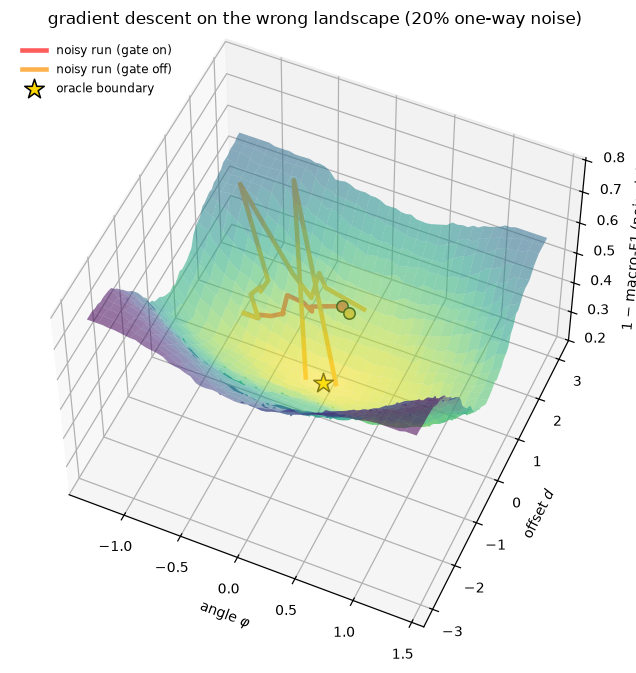

In [6]:
# the same descent in 3D: the noisy surface with the gated and ungated trajectories draped on it
from matplotlib import cm
fig = plt.figure(figsize=(9.5, 6))
ax = fig.add_subplot(projection="3d")
step = 2
ax.plot_surface(PHI[::step, ::step], D[::step, ::step], L_noisy[::step, ::step],
                cmap="viridis_r", alpha=0.55, linewidth=0, antialiased=True)
for res, col, lab in ((res_gate, "#ff5c5c", "gate on"), (res_nogate, "#ffb14e", "gate off")):
    tp, td = traj(res)
    tpw, tdw, _ = in_window(tp, td)
    tl = []
    for p, d in zip(tpw, tdw):
        if not np.isfinite(p):
            tl.append(np.nan); continue
        i = np.clip(np.searchsorted(phis, p), 0, len(phis)-1)
        j = np.clip(np.searchsorted(offs, d), 0, len(offs)-1)
        tl.append(L_noisy[i, j])
    tl = np.array(tl)
    ax.plot(tpw, tdw, tl + 0.05, color=col, lw=3.0, label=f"noisy run ({lab})")
    fin = np.where(np.isfinite(tpw))[0]
    if len(fin):
        ax.scatter(tpw[fin[-1]], tdw[fin[-1]], tl[fin[-1]] + 0.05,
                   color=col, s=55, edgecolor="k")
ax.scatter([phi_o], [d_o], [L_noisy[np.searchsorted(phis, phi_o),
                                    np.searchsorted(offs, d_o)] + 0.05],
           color="gold", marker="*", s=180, edgecolor="k", label="oracle boundary")
ax.set(xlabel=r"angle $\varphi$", ylabel=r"offset $d$", zlabel="1 − macro-F1 (noisy labels)",
       title="gradient descent on the wrong landscape (20% one-way noise)")
ax.view_init(elev=52, azim=-66)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()

## 4 · Anatomy of one run: a noisy universe and its clean twin

One world, one seed, **30% one-way boundary noise**. The clean twin shares every random draw —
batches, judge noise, SME coin-flips — so any gap between the curves is *caused by the labels*,
nothing else. Watch four things: the oracle-F1 gap (damage), the decision-disagreement between the
twins (divergence in document space), the confidence posterior separating flipped from clean
labels (the posterior is tracked on every run; this run leaves anchor weights at `off` — §7
turns the weighting on), and the learned boundaries at the end.


final F1: noisy 0.657 vs clean 0.898 | divergence 0.164 | detection AUROC 0.629


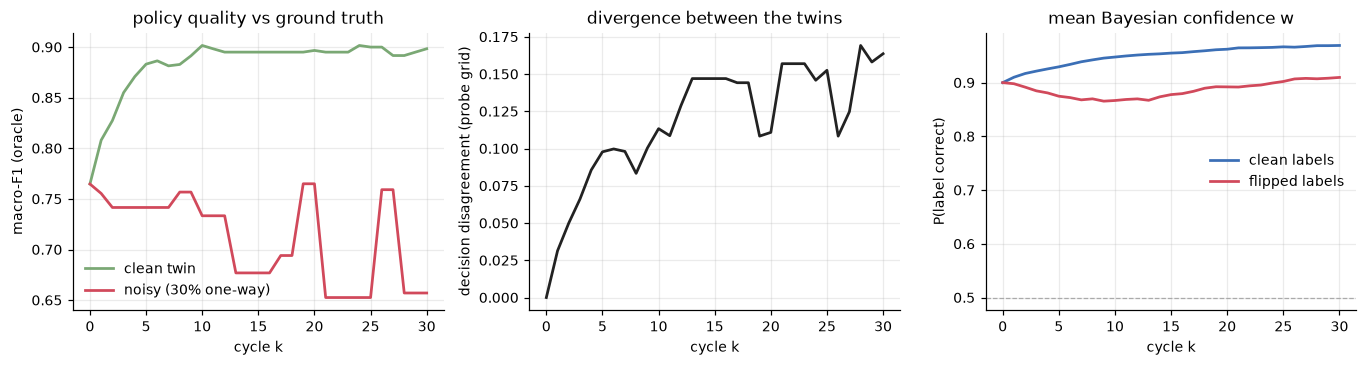

In [7]:
cfg = base_config("genai", seed=SEED, noise=suite_noise("genai", rate=0.3))
ds, labels = build_world(cfg)
res_n = run_crank(cfg, ds=ds, labels=labels)
res_c = run_crank(cfg, ds=ds, labels=clean_labels(ds))
div = divergence_series(res_n, res_c)
s_n, s_c = res_n["series"], res_c["series"]
ks = s_n["k"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot(ks, s_c["policy_f1_true"], color=CC, lw=1.8, label="clean twin")
axes[0].plot(ks, s_n["policy_f1_true"], color=C1, lw=1.8, label="noisy (30% one-way)")
axes[0].set(title="policy quality vs ground truth", xlabel="cycle k", ylabel="macro-F1 (oracle)")
axes[0].legend()
axes[1].plot(ks, div["decision_disagreement"], color=CN, lw=1.8)
axes[1].set(title="divergence between the twins", xlabel="cycle k",
            ylabel="decision disagreement (probe grid)")
axes[2].plot(ks, s_n["w_mean_clean"], color=C0, lw=1.8, label="clean labels")
axes[2].plot(ks, s_n["w_mean_flipped"], color=C1, lw=1.8, label="flipped labels")
axes[2].axhline(0.5, color="#aaa", lw=0.8, ls="--")
axes[2].set(title="mean Bayesian confidence w", xlabel="cycle k", ylabel="P(label correct)")
axes[2].legend()
plt.tight_layout()
print(f"final F1: noisy {s_n['policy_f1_true'][-1]:.3f} vs clean {s_c['policy_f1_true'][-1]:.3f}"
      f" | divergence {div['decision_disagreement'][-1]:.3f}"
      f" | detection AUROC {s_n['detection_auroc'][-1]:.3f}")

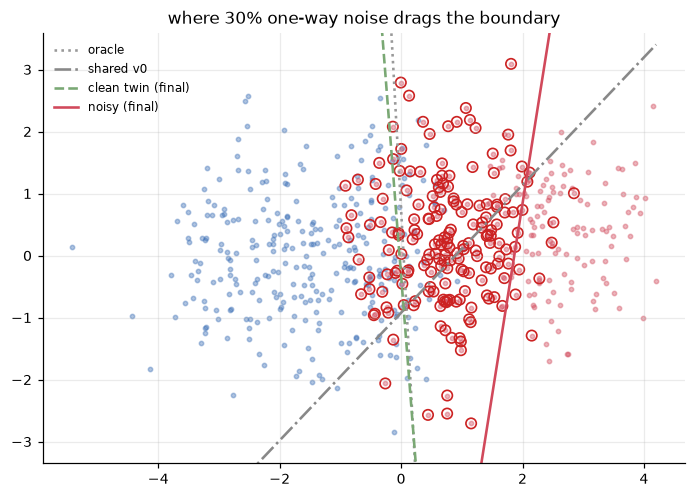

In [8]:
# the boundaries themselves — where the noise dragged the document
fig, ax = plt.subplots(figsize=(6.4, 4.6))
for c, col in ((0, C0), (1, C1)):
    m = ds.y == c
    ax.scatter(ds.X[m, 0], ds.X[m, 1], s=8, alpha=0.4, color=col)
fm = labels[1]
ax.scatter(ds.X[fm, 0], ds.X[fm, 1], s=46, facecolors="none", edgecolors="#c22",
           linewidths=1.1)
xs = np.linspace(ds.X[:, 0].min(), ds.X[:, 0].max(), 50)
for pol, style, col, lab in ((res_n["oracle"], ":", CO, "oracle"),
                             (res_n["snapshots"][0], "-.", "#888", "shared v0"),
                             (res_c["policy"], "--", CC, "clean twin (final)"),
                             (res_n["policy"], "-", C1, "noisy (final)")):
    w, b = pol.w, pol.b
    ax.plot(xs, -(w[0] * xs + b) / w[1], style, color=col, lw=1.7, label=lab)
ax.set_ylim(ds.X[:, 1].min() - 0.5, ds.X[:, 1].max() + 0.5)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("where 30% one-way noise drags the boundary")
plt.tight_layout()


## 5 · Measured vs theoretical divergence

The payoff figure. For each noise rate we run the crank (uniform one-way noise, 6 seeds, 40
cycles), take the final boundary, and measure its **displacement along the true-boundary normal**
$\Delta = t^*_{\text{final}} - t^*_{\text{oracle}}$ — the same quantity §2 predicts. Curves:

- **accuracy-Bayes theory** (closed form): $\Delta = \operatorname{logit}(c^*)/\hat\beta$,
  collapsing at rate 0.25;
- **noisy-metric optimum**: the macro-F1-optimal threshold under the noisy labels (computed
  numerically on the big sample) — what a gate that maximizes the noisy metric would ideally pick;
- **full-fit counterfactual**: a plain logistic fit to ALL the noisy labels — what naive training
  on the corrupted data does. It lands well ABOVE the closed form, because the linear model is
  misspecified for the scaled posterior $(1-\rho_1)\,\eta(x)$ (its ceiling is $1-\rho_1$, so the
  fit compensates by over-rotating);
- **measured**, gate off vs gate on.

Displacement along a normal only means something while the boundary stays broadly oriented like
the oracle, so runs whose final orientation drifts past 45° (cosine < 0.7 to the oracle normal)
are excluded from the error bars and **counted per point**. For gated runs, losing orientation is
the §2 collapse showing up at finite parameters; ungated runs also shed orientation from generic
instability at any rate — see the reading note below.


clean-run noise floor: |Δ| = 0.151
collapsed/disoriented runs per rate:  gate off [1, 3, 2, 3, 2, 3, 2]  gate on [0, 0, 0, 0, 0, 1, 2]


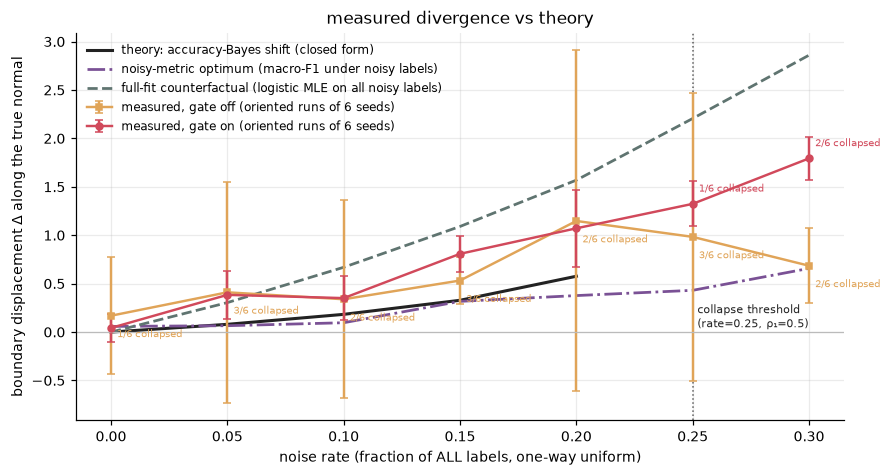

In [9]:
def t_star(pol):
    denom = pol.w @ N_HAT
    if abs(denom) < 0.15 * np.linalg.norm(pol.w):   # near-orthogonal: offset undefined
        return np.nan
    return float(-(pol.w @ X0 + pol.b) / denom)

T_ORC = t_star(ORC)

def f1_opt_threshold(y_labels):
    zz = z_of(BIG.X)
    ts = np.quantile(zz, np.linspace(0.02, 0.98, 200))
    best_t, best = ts[0], -1
    for t in ts:
        f1 = macro_f1(y_labels, (zz > t).astype(int), 2)
        if f1 > best: best, best_t = f1, t
    return best_t

RATES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
theory_acc = [delta_theory(r) for r in RATES]
mle_fit = []      # full-batch logistic fit to the noisy labels (misspecified model)
theory_f1 = []
for r in RATES:
    shifts = []
    for s in (1, 2, 3):
        y_noisy, _ = apply_noise(BIG, NoiseConfig(model="uniform", rate=r, flip_from=1),
                                 seed=SEED + s, oracle=ORC)
        # same zero reference as the measured curve: the oracle crossing T_ORC
        shifts.append(f1_opt_threshold(y_noisy) - T_ORC)
    theory_f1.append(np.mean(shifts))
    fits = []
    for s in (1, 2, 3):
        y_noisy, _ = apply_noise(BIG, NoiseConfig(model="uniform", rate=r, flip_from=1),
                                 seed=SEED + s, oracle=ORC)
        pol = LogisticPolicy.fit(BIG.X, y_noisy, steps=2000, lr=0.5)
        fits.append(t_star(pol) - T_ORC)
    mle_fit.append(np.mean(fits))

meas = {"on": [], "off": []}
lost = {"on": [], "off": []}
clean_deltas = []
for r in RATES:
    for gate in ("on", "off"):
        ds_list, n_lost = [], 0
        for s in range(6):
            cfg_r = base_config("genai", seed=SEED + 100*s, cycles=40, gate=gate,
                                noise=NoiseConfig(model="uniform", rate=r, flip_from=1,
                                                  target="both"))
            res = run_crank(cfg_r)
            pol = res["policy"]
            orc_r = res["oracle"]
            cos = (pol.w @ orc_r.w) / (np.linalg.norm(pol.w) * np.linalg.norm(orc_r.w))
            d = t_star(pol)
            if cos < 0.7 or not np.isfinite(d):   # disoriented = finite-run collapse
                n_lost += 1
                continue
            ds_list.append(d - t_star(orc_r))
            if gate == "on" and r == 0.0:
                clean_deltas.append(ds_list[-1])
        meas[gate].append(mean_ci(ds_list) if ds_list else (np.nan, np.nan))
        lost[gate].append(n_lost)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
rr = np.array(RATES)
ax.plot(rr, theory_acc, "-", color=CN, lw=2.0, label="theory: accuracy-Bayes shift (closed form)")
ax.axvline(0.25, color=CN, lw=1.0, ls=":", alpha=0.7)
ax.text(0.252, 0.05, "collapse threshold\n(rate=0.25, ρ₁=0.5)", fontsize=7.5, color=CN)
ax.plot(rr, theory_f1, "-.", color="#7a5195", lw=1.8,
        label="noisy-metric optimum (macro-F1 under noisy labels)")
ax.plot(rr, mle_fit, "--", color="#5f7470", lw=1.8,
        label="full-fit counterfactual (logistic MLE on all noisy labels)")
for gate, col, mk in (("off", "#e0a458", "s"), ("on", "#d1495b", "o")):
    mu = np.array([m[0] for m in meas[gate]]); ci = np.array([m[1] for m in meas[gate]])
    ax.errorbar(rr, mu, yerr=ci, marker=mk, ms=4.5, lw=1.6, capsize=2.5, color=col,
                label=f"measured, gate {gate} (oriented runs of 6 seeds)")
    for x, y, n in zip(rr, mu, lost[gate]):
        if n:
            ax.annotate(f"{n}/6 collapsed", (x, y if np.isfinite(y) else 0),
                        textcoords="offset points", xytext=(4, -14 if gate == "off" else 8),
                        fontsize=6.5, color=col)
ax.axhline(0, color="#bbb", lw=0.8)
ax.set(xlabel="noise rate (fraction of ALL labels, one-way uniform)",
       ylabel="boundary displacement Δ along the true normal",
       title="measured divergence vs theory")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
print(f"clean-run noise floor: |Δ| = {np.nanmean(np.abs(clean_deltas)):.3f}")
print("collapsed/disoriented runs per rate:  gate off", lost["off"], " gate on", lost["on"])


Reading it — two results, one expected and one that was not:

1. **The collapse arrives on schedule — in the gated runs.** Gate-on displacement grows
   monotonically with rate, and gated runs start losing orientation exactly past the §2
   threshold (0/6 collapsed at every rate ≤ 0.2, then 1/6 at 0.25 and 2/6 at 0.3) — the
   finite-parameter version of $\Delta \to \infty$. Ungated runs shed orientation at every rate
   *including zero*: without the gate, clipped anchor steps random-walk freely — a reminder of
   what the gate is for, and why gate-off exclusion counts mix generic instability with true
   collapse.
2. **The crank overshoots the closed form — but undershoots naive training.** Measured gate-on
   displacement runs ~2× the accuracy-Bayes curve at this horizon. Our first hypothesis — that
   anchors importance-sample the mislabels ("wrong labels complain forever") and amplify the bias
   beyond ordinary fitting — **did not survive its counterfactual**: a plain logistic fit to ALL
   the noisy labels (the grey dashed curve) displaces *more* than the crank does (e.g. 1.57 vs
   1.05 at rate 0.2). The closed form describes an idealized well-specified learner; any linear
   model fit to the scaled posterior over-rotates (misspecification), and THAT is the realistic
   no-defense baseline. Against it, the gate + edit clipping recover roughly a third to half of
   the drift — the regularizers are genuine divergence brakes, just measured against the right
   counterfactual. The falsified hypothesis is worth keeping on the record: the anchor mechanism
   *concentrates attention* on mislabels (see §11's contamination numbers) without adding net
   displacement beyond what the labels themselves demand.


## 6 · S1 — dose-response: how much noise bends the trajectory

No mitigation. Each cell = mean ± 95% CI over seeds; divergence is measured against each run's
clean twin. Two geometry lessons: **one-way flips hurt far more than two-sided** — that one is
§2's prediction (symmetric noise leaves the threshold fixed; directional confusion drags it) —
and **interior (uniform) mislabels hurt more than boundary mislabels** at the same rate, a
lever-arm effect the world's geometry adds on top of the theory.


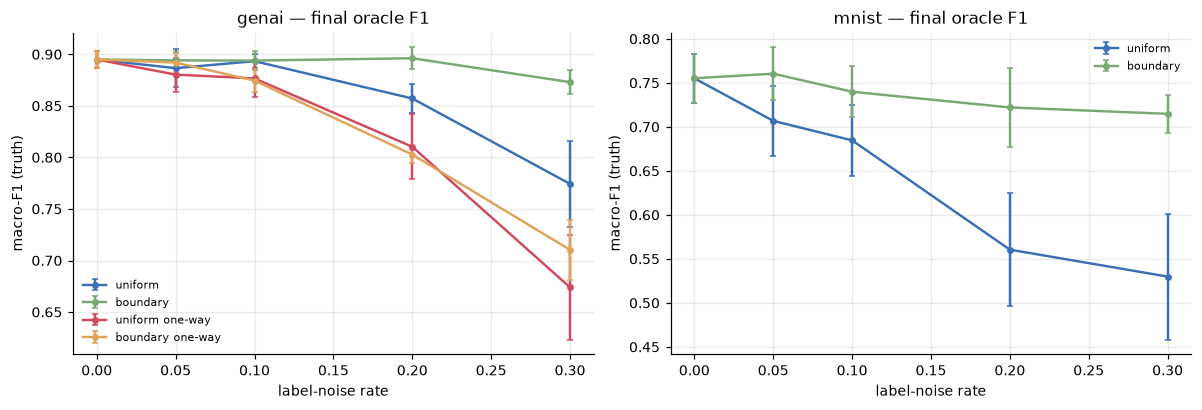

In [10]:
N_SEEDS = 8  # notebook-sized; the CLI sweep uses 12
s1g = s1_dose_response("genai", n_seeds=N_SEEDS)
s1m = s1_dose_response("mnist", n_seeds=N_SEEDS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, s1, title in ((axes[0], s1g, "genai — final oracle F1"),
                      (axes[1], s1m, "mnist — final oracle F1")):
    variants = {}
    for c in s1["cells"]:
        key = c["model"] + (" one-way" if c.get("one_way") else "")
        variants.setdefault(key, []).append(c)
    for (key, cc), col in zip(variants.items(), ("#3b6fb6", "#7aa874", "#d1495b", "#e0a458")):
        rates = [c["rate"] for c in cc]
        mu = [c["final_oracle_f1"][0] for c in cc]
        ci = [c["final_oracle_f1"][1] for c in cc]
        ax.errorbar(rates, mu, yerr=ci, marker="o", ms=3.5, lw=1.6, capsize=2,
                    color=col, label=key)
    ax.set(title=title, xlabel="label-noise rate", ylabel="macro-F1 (truth)")
    ax.legend(fontsize=7.5)
plt.tight_layout()

## 7 · S2 — does the weighting methodology converge to the right answer?

The arms, with noise in **both** splits (the same SMEs label train and test — with a clean test
set the gate is secretly an oracle and rescues almost any run):

- **deweight / deweight_hard** — anchor weight = posterior w (or dropped when w < 0.5): *learn to ignore*.
- **upweight** — anchor weight = 1 + (1−w): the parallel universe that *hyper-focuses*, assuming the human is right.
- **readj_?** — budgeted SME review (5 train + 3 test per cycle), queue ordered by stack-rank / PPS / random;
  the SME returns truth with p=0.95, and confirmed labels go back to full weight.

Two regimes on purpose: genai flips 30% of ALL labels one-way (= 60% of the gen_ai class — a
stress test past the §2 collapse threshold), mnist uses two-sided boundary noise (the calibrated
regime).


genai: emergent overturn rate among reviewed items 0.73 (empirical band from real re-adjudication: 0.33-0.44)
mnist: emergent overturn rate among reviewed items 0.34 (empirical band from real re-adjudication: 0.33-0.44)


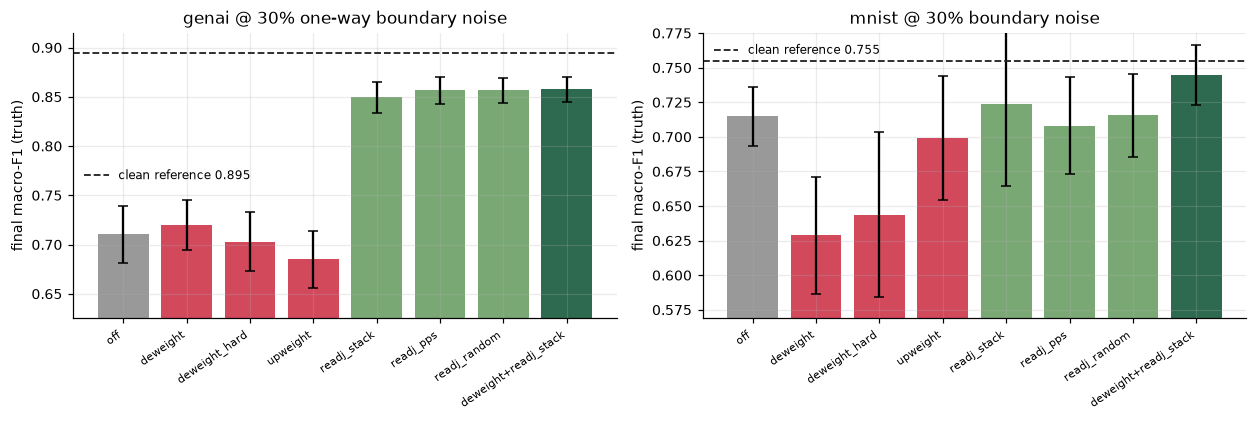

In [11]:
s2g = s2_mitigation("genai", n_seeds=N_SEEDS)
s2m = s2_mitigation("mnist", n_seeds=N_SEEDS)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for ax, s2, title in ((axes[0], s2g, "genai @ 30% one-way boundary noise"),
                      (axes[1], s2m, "mnist @ 30% boundary noise")):
    arms = [c["arm"] for c in s2["cells"]]
    mu = [c["final_oracle_f1"][0] for c in s2["cells"]]
    ci = [c["final_oracle_f1"][1] for c in s2["cells"]]
    cols = ["#999" if a == "off" else "#d1495b" if "readj" not in a
            else "#7aa874" if a.startswith("readj") else "#2d6a4f" for a in arms]
    ax.bar(range(len(arms)), mu, yerr=ci, capsize=3, color=cols)
    ax.axhline(s2["clean_reference_f1"][0], color="#222", lw=1.2, ls="--",
               label=f"clean reference {s2['clean_reference_f1'][0]:.3f}")
    ax.set_xticks(range(len(arms)))
    ax.set_xticklabels(arms, rotation=35, ha="right", fontsize=7.5)
    lo = min(mu) - 0.06
    ax.set_ylim(lo, max(s2["clean_reference_f1"][0], max(mu)) + 0.02)
    ax.set(title=title, ylabel="final macro-F1 (truth)")
    ax.legend(fontsize=8)
plt.tight_layout()
for name, s2 in (("genai", s2g), ("mnist", s2m)):
    ov = [c["emergent_overturn_rate"][0] for c in s2["cells"]
          if not np.isnan(c["emergent_overturn_rate"][0])]
    print(f"{name}: emergent overturn rate among reviewed items {np.mean(ov):.2f} "
          f"(empirical band from real re-adjudication: 0.33-0.44)")

**The headline.** Weighting alone does not converge — it cannot repair the gate's corrupted
yardstick. Under genai's heavy directional corruption it nudges (+0.02 in the 12-seed CLI sweep); in mnist's calibrated
regime soft deweighting is *worse than doing nothing*: early in a run the posterior cannot
distinguish a hard-but-correct boundary label from a wrong one, so deweighting throws away exactly
the boundary evidence the prototypes need. **Deweight + re-adjudication is the winning
combination**: the confidence posterior's real job is *routing scarce SME attention* (after
review, confirmed labels return to full weight; overturned ones are fixed). Learn-to-ignore and
hyper-focus are both wrong as label policies — the right move is *triage, then repair*.

The mnist regime's emergent overturn rate lands in the empirically observed 33–44% band with no
tuning; the genai stress cell overturns at ~0.74, as 60%-of-a-class corruption should.


## 8 · S3 — parallel universes: did this label ever matter?

Twin runs that differ **only** in what they assume about suspect labels — deweight (assume the
panel is right) vs upweight (assume the human is right) — plus per-point influence probes: one
label pinned to weight 0 vs 2, short twin horizon, divergence measured. The test: *if the policy
stays stable in document space, these points never mattered much.*


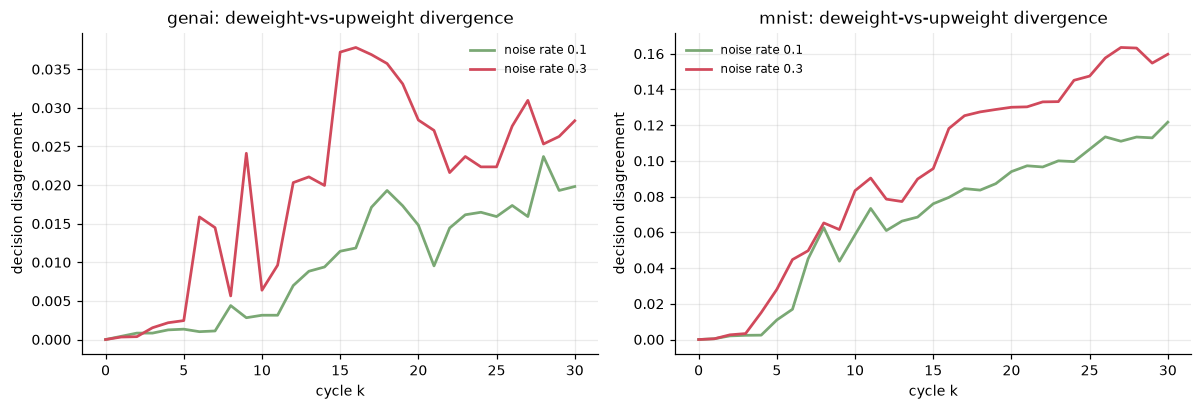

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, name in zip(axes, ("genai", "mnist")):
    for rate, col in ((0.1, "#7aa874"), (0.3, "#d1495b")):
        dd = []
        for seed in [SEED + 100 * i for i in range(6)]:
            c = base_config(name, seed=seed, noise=suite_noise(name, rate=rate))
            _, _, d = run_pair(c, a={"weighting": "deweight"}, b={"weighting": "upweight"})
            dd.append(d["decision_disagreement"])
        m = np.mean(np.array(dd), axis=0)
        ax.plot(range(len(m)), m, color=col, lw=1.8, label=f"noise rate {rate}")
    ax.set(title=f"{name}: deweight-vs-upweight divergence", xlabel="cycle k",
           ylabel="decision disagreement")
    ax.legend(fontsize=8)
plt.tight_layout()

mean influence: flipped 0.0075 vs clean 0.0000 (clean ~ 0: flipped points carry essentially ALL the influence) — n=24/24


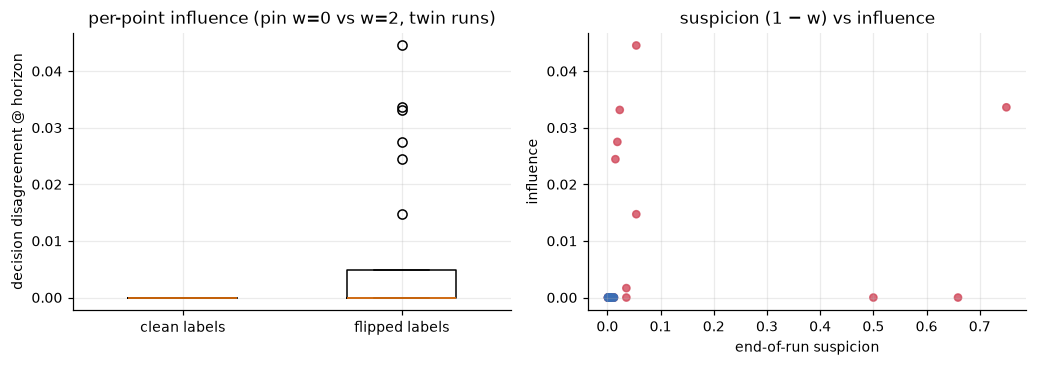

In [13]:
infl = []
for seed in (SEED, SEED + 100):
    cfg_i = base_config("genai", seed=seed, noise=suite_noise("genai", rate=0.2))
    infl.extend(point_influence(cfg_i))
fl = [r["influence_dd"] for r in infl if r["is_flipped"]]
cl = [r["influence_dd"] for r in infl if not r["is_flipped"]]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].boxplot([cl, fl], tick_labels=["clean labels", "flipped labels"], widths=0.5)
axes[0].set(title="per-point influence (pin w=0 vs w=2, twin runs)",
            ylabel="decision disagreement @ horizon")
axes[1].scatter([r["suspicion"] for r in infl], [r["influence_dd"] for r in infl],
                c=[C1 if r["is_flipped"] else C0 for r in infl], s=22, alpha=0.8)
axes[1].set(title="suspicion (1 − w) vs influence", xlabel="end-of-run suspicion",
            ylabel="influence")
plt.tight_layout()
ratio = (f"{np.mean(fl)/np.mean(cl):.1f}x" if np.mean(cl) > 1e-4
         else "clean ~ 0: flipped points carry essentially ALL the influence")
print(f"mean influence: flipped {np.mean(fl):.4f} vs clean {np.mean(cl):.4f} ({ratio}) "
      f"— n={len(fl)}/{len(cl)}")

In the gated binary world the twins barely diverge — those suspects mostly "never mattered much."
In multiclass they diverge substantially: the assumption you make about suspect labels changes the
document you end up with. The per-point probe compares RANDOM flipped vs random clean items (not
top-suspicion — that would confound the comparison with the detector's own selection): on genai
clean points carry essentially zero influence — the flipped ones carry all of it; on mnist the per-point gap narrows because
individual boundary flips matter little one at a time even though collectively they diverge the
twins. Influence is a candidate *queue score* for SME attention (see §11).

## 9 · S4 — the test set is not optional

Noise **only** in the test partition. The gate compares candidate vs incumbent on human test
labels, so test mislabels directly corrupt accept/reject decisions — false-accepts (steps the
truth-scored gate would reject) and false-rejects (improvements thrown away).


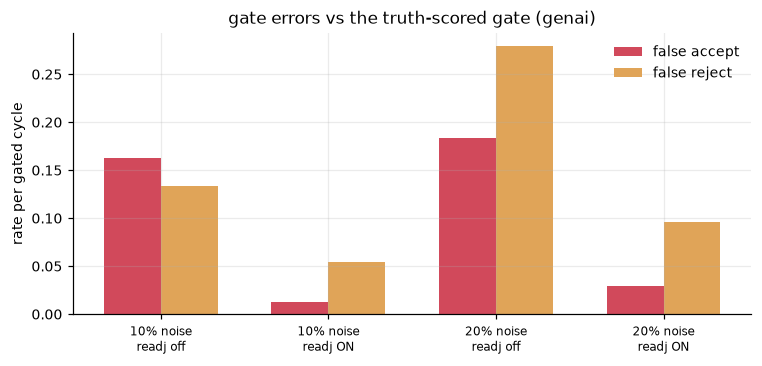

In [14]:
s4 = s4_test_corruption("genai", n_seeds=N_SEEDS)
labs, fa, fr = [], [], []
for c in s4["cells"]:
    labs.append(f"{int(c['rate']*100)}% noise\nreadj {'ON' if c['readj_test'] else 'off'}")
    fa.append(c["gate_false_accept_rate"][0])
    fr.append(c["gate_false_reject_rate"][0])
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(x - 0.17, fa, width=0.34, color="#d1495b", label="false accept")
ax.bar(x + 0.17, fr, width=0.34, color="#e0a458", label="false reject")
ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8)
ax.set(title="gate errors vs the truth-scored gate (genai)", ylabel="rate per gated cycle")
ax.legend()
plt.tight_layout()

Re-adjudicating the test partition (5 reviews/cycle, stack-ranked by accumulated panel
disagreement) collapses gate corruption by roughly an order of magnitude. **The gate's yardstick
deserves SME attention as much as the anchors do** — and this is also the quantitative argument
for keeping the test set relatively large and well-audited (the fixed-yardstick design).

## 10 · S5 — sampling strategy under contamination

Anchors are selected from persistently-misaligned items — and mislabels are *persistently*
misaligned, so the anchor pool self-enriches in exactly the wrong points (the hyper-focus
mechanism). Does deterministic stack-ranking make that worse than PPS / random sampling?


In [15]:
s5 = s5_sampling("genai", n_seeds=N_SEEDS)
print(f"{'strategy':<12} {'rate':<6} {'final F1':<16} {'anchor gini':<14} {'contamination'}")
for c in s5["cells"]:
    f1, ci = c["final_oracle_f1"]; g, _ = c["anchor_gini"]; ct, cti = c["anchor_contamination"]
    print(f"{c['strategy']:<12} {c['rate']:<6} {f1:.3f} ± {ci:.3f}    {g:.2f}          "
          f"{ct:.2f} ± {cti:.2f}")

strategy     rate   final F1         anchor gini    contamination
stack_rank   0.0    0.895 ± 0.009    0.33          0.00 ± 0.00
stack_rank   0.2    0.810 ± 0.031    0.68          0.54 ± 0.04
pps          0.0    0.894 ± 0.011    0.32          0.00 ± 0.00
pps          0.2    0.803 ± 0.022    0.62          0.51 ± 0.04
random       0.0    0.894 ± 0.009    0.33          0.00 ± 0.00
random       0.2    0.800 ± 0.031    0.65          0.52 ± 0.05


At 20% uniform noise the anchor pool runs heavily enriched in mislabels, and anchor picks
CONCENTRATE (Gini over ever-eligible items roughly doubles under noise, stack-rank most
concentrated) — the hyper-focus mechanism is real and visible. Final F1 still lands within each
strategy's CI: the gate limits the damage any one selection rule can do. The live strategy
question moved to the **SME queue** (S2: at these rates, random ≈ PPS ≈ stack-rank on equal
budget, because almost any review hits a mislabel; at low rates ranking quality should matter
more — sweep `rate × strategy` before concluding).



## 11 · S6 — the breakdown map: what does 10 / 20 / 30 / 50% wrong look like?

The question, run as a suite: sweep the corrupted fraction up to HALF of all labels, across the
noise geometries, with no mitigation vs the best strategy from §7 (deweight + stack-ranked SME
review of train and test, 5+3 reviews/cycle). And watch the anchors — they are drawn from the
persistent misalignments, which is exactly where mislabels concentrate, so the anchor pool
saturates long before the topline F1 moves.


anchor pool under genai noise (share of anchor picks that are mislabeled):
geometry          rate                off     deweight+readj
boundary           0.1    42% (4.2x base)     7% (0.7x base)
boundary           0.2    85% (4.2x base)    27% (1.4x base)
boundary           0.3    95% (3.2x base)    57% (1.9x base)
boundary           0.5    96% (1.9x base)    85% (1.7x base)
uniform            0.1    44% (4.4x base)    12% (1.2x base)
uniform            0.2    61% (3.0x base)    28% (1.4x base)
uniform            0.3    68% (2.3x base)    43% (1.4x base)
uniform            0.5    58% (1.2x base)    62% (1.2x base)
boundary one-way   0.1    28% (2.8x base)     7% (0.7x base)
boundary one-way   0.2    54% (2.7x base)    22% (1.1x base)
boundary one-way   0.3    72% (2.4x base)    44% (1.5x base)
boundary one-way   0.5    75% (1.5x base)    63% (1.3x base)


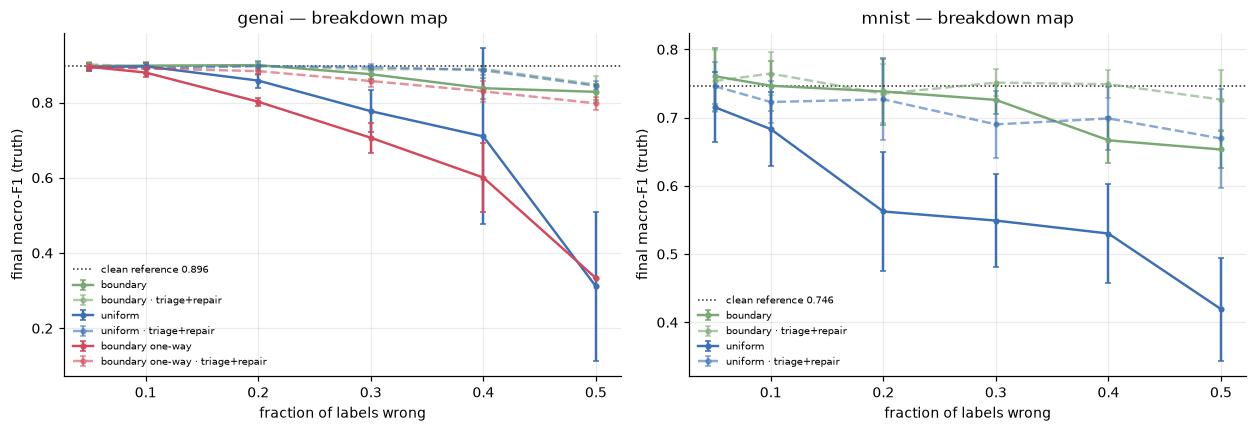

In [16]:

s6g = s6_breakdown("genai", n_seeds=6)
s6m = s6_breakdown("mnist", n_seeds=6)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
GEO_COL = {("boundary", False): "#7aa874", ("uniform", False): "#3b6fb6",
           ("boundary", True): "#d1495b"}
for ax, s6 in ((axes[0], s6g), (axes[1], s6m)):
    for (model, ow), col in GEO_COL.items():
        for arm, style in (("off", "-"), ("dw+readj", "--")):
            cc = [c for c in s6["cells"]
                  if c["model"] == model and c["one_way"] == ow and c["arm"] == arm]
            if not cc:
                continue
            rates = [c["rate"] for c in cc]
            mu = [c["final_oracle_f1"][0] for c in cc]
            ci = [c["final_oracle_f1"][1] for c in cc]
            lab = model + (" one-way" if ow else "") + (" · triage+repair" if arm != "off" else "")
            ax.errorbar(rates, mu, yerr=ci, marker="o", ms=3, lw=1.6, ls=style,
                        capsize=2, color=col, alpha=1.0 if arm == "off" else 0.6,
                        label=lab)
    ax.axhline(s6["clean_reference_f1"][0], color="#222", lw=1.0, ls=":",
               label=f"clean reference {s6['clean_reference_f1'][0]:.3f}")
    ax.set(title=f"{s6['dataset']} — breakdown map", xlabel="fraction of labels wrong",
           ylabel="final macro-F1 (truth)")
    ax.legend(fontsize=6.5)
plt.tight_layout()

print("anchor pool under genai noise (share of anchor picks that are mislabeled):")
print(f"{'geometry':<16} {'rate':>5} {'off':>18} {'deweight+readj':>18}")
for model, ow in GEO_COL:
    for rate in (0.1, 0.2, 0.3, 0.5):
        row = {}
        for arm in ("off", "dw+readj"):
            c = next(c for c in s6g["cells"] if c["model"] == model
                     and c["one_way"] == ow and c["rate"] == rate and c["arm"] == arm)
            ct, _ = c["anchor_contamination"]; en, _ = c["anchor_enrichment"]
            row[arm] = f"{ct:.0%} ({en:.1f}x base)"
        tag = model + (" one-way" if ow else "")
        print(f"{tag:<16} {rate:>5} {row['off']:>18} {row['dw+readj']:>18}")


Reading the map (the 8-seed CLI sweep in `results/s6_*.json` agrees with the 6-seed cells above):

- **The anchors saturate first.** At just 10% boundary noise, ~40% of the unmitigated run's
  anchors are mislabeled (4× enrichment over the base rate); by 20% it is ~84%. The drafter's
  reading list is majority-wrong long before the topline F1 shows it — the catastrophic-anchor
  mechanism in one number. Triage+repair keeps contamination at or below the base rate at low
  rates: the queue actively cleans the anchor stream.
- **Where it breaks, unmitigated:** boundary two-sided noise is nearly harmless out to 40% (those
  flips are the ambiguous cases anyway); interior (uniform) noise holds to ~30% and then falls
  off a cliff (0.774 @ 30% → 0.387 @ 50%, with huge seed variance near the cliff); one-way noise
  degrades steadily from 10% and hits total class collapse at 50% (macro-F1 0.333 with zero
  variance — the degenerate all-one-class fixed point).
- **Triage+repair never cliffs** in this sweep: worst cases 0.80 (genai one-way @ 50%) and 0.67
  (mnist uniform @ 50%). With HALF the labels wrong, 5+3 reviews/cycle plus soft deweighting keep
  the run within sight of its clean reference.

## 12 · S7 — do starting conditions matter? (the randomize-v0 question)

Same world, same labels, same random streams — only the starting policy varies (6 independent v0
draws per world; `badstart` widens the v0 misspecification from 30–60° to 60–120°). If the final
policies land together, the crank is well-posed and the v0 lottery washes out; if they scatter,
the optimizer is sensitive to initial conditions — the Lyapunov question, in miniature.


genai  clean           pairwise disagreement 0.021±0.018   F1 0.894 (spread 0.017)
genai  noisy           pairwise disagreement 0.027±0.004   F1 0.807 (spread 0.055)
genai  noisy_badstart  pairwise disagreement 0.028±0.010   F1 0.804 (spread 0.046)
mnist  clean           pairwise disagreement 0.264±0.018   F1 0.736 (spread 0.168)
mnist  noisy           pairwise disagreement 0.289±0.011   F1 0.721 (spread 0.174)
mnist  noisy_badstart  pairwise disagreement 0.289±0.011   F1 0.721 (spread 0.174)


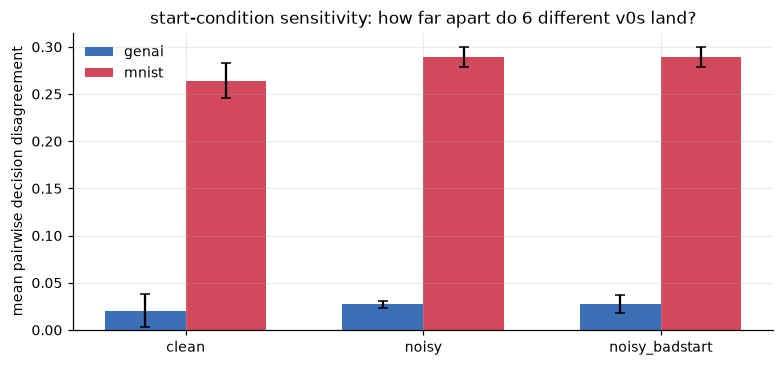

In [17]:

s7g = s7_init_sensitivity("genai", n_seeds=4, m_inits=6)
s7m = s7_init_sensitivity("mnist", n_seeds=4, m_inits=6)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
conds = [c["condition"] for c in s7g["cells"]]
x = np.arange(len(conds))
for off, s7, col, lab in ((-0.17, s7g, "#3b6fb6", "genai"), (0.17, s7m, "#d1495b", "mnist")):
    mu = [c["pairwise_decision_disagreement"][0] for c in s7["cells"]]
    ci = [c["pairwise_decision_disagreement"][1] for c in s7["cells"]]
    ax.bar(x + off, mu, yerr=ci, width=0.34, capsize=3, color=col, label=lab)
ax.set_xticks(x); ax.set_xticklabels(conds)
ax.set(title="start-condition sensitivity: how far apart do 6 different v0s land?",
       ylabel="mean pairwise decision disagreement")
ax.legend()
plt.tight_layout()
for name, s7 in (("genai", s7g), ("mnist", s7m)):
    for c in s7["cells"]:
        dd, ddci = c["pairwise_decision_disagreement"]
        f1, _ = c["final_f1_mean"]; sp, _ = c["final_f1_spread"]
        print(f"{name:6s} {c['condition']:15s} pairwise disagreement {dd:.3f}±{ddci:.3f}"
              f"   F1 {f1:.3f} (spread {sp:.3f})")


Two very different answers. The **binary world is start-condition-immune**: six v0s — even
60–120° bad starts — land within 0.02–0.03 decision disagreement of each other, noisy or clean;
the gate funnels every start into the same basin. The **multiclass world is intrinsically
start-sensitive**: pairwise disagreement 0.26–0.29 with a final-F1 spread of ~0.17 — ten
prototypes in a plane admit many locally-optimal assignments, and which one you reach is decided
by v0, *not* by the labels (noise adds almost nothing: 0.264 → 0.289). Initial conditions and
label noise are close to orthogonal risk axes.

The real-crank implication: a policy document with dozens of clauses is more mnist-like than
genai-like — expect the v0 lottery to matter independently of label quality. Measuring it there
is the Lyapunov experiment from the research agenda: same config, several regenerated v0s (or
seeds), embed the final policy markdowns, compare pairwise distances against the same-seed noise
floor. That needs real LLM labeling runs (each v0 arm re-labels everything — the label cache only
helps byte-identical v0 legs), which is exactly why the sim's forecast is worth having first.


## 13 · Takeaways — and how we test this on the real crank

**What the sim established:**

1. **Theory pins the failure mode, and the crank sits between two reference curves** (§2, §5):
   one-way label noise shifts the accuracy-optimal boundary by `logit(1/(2(1−ρ₁)))/β`, collapsing
   the class at ρ₁ ≥ 0.5; two-sided noise cancels. A naive full fit of the noisy labels lands
   well ABOVE that closed form (model misspecification); the crank lands between the two — its
   gate + edit clipping recover a third to half of the naive-fit drift. (Our first hypothesis,
   that anchors importance-sample mislabels and amplify beyond ordinary fitting, was tested
   against the full-fit counterfactual and rejected — anchors *concentrate attention* on
   mislabels (§11) without adding net displacement.)
2. **Weighting alone does not converge** (§7) — and soft deweighting can be worse than nothing.
   Its value is **triage**: route SME attention, then restore confirmed weights.
3. **Deweight + budgeted re-adjudication converges** to within noise of the clean-label run in
   the calibrated mnist regime (0.746 vs 0.755; genai's 60%-of-a-class stress cell recovers 0.86
   of a 0.19 hole), and its emergent overturn rate brackets the empirical 33–44% band untuned.
4. **Re-adjudicate the test set** (§9) — at 10–20% test-label noise roughly 3 gate decisions in
   10 are wrong against a truth-scored gate (FA+FR 0.29–0.46); a ~5-review/cycle test queue cuts
   that by an order of magnitude.
5. **Influence probes** (§8) identify labels the document's fate hinges on — a candidate queue
   score beyond disagreement mass.
6. **The breakdown map** (§11): the anchor pool saturates with mislabels long before topline F1
   moves (~40% contaminated at 10% noise, ~84% at 20%). Unmitigated runs cliff at 30–50%
   depending on geometry (one-way earliest); triage+repair never cliffs through 50% wrong labels.
7. **Starting conditions are their own risk axis** (§12): the binary crank is well-posed (all v0s
   converge, even bad ones); the multiclass crank is start-sensitive *independent of label
   noise*. Expect the policy document to behave like the multiclass case — the real-crank
   Lyapunov run (same config, regenerated v0s, embed the final policies) needs LLM labeling
   budget and is worth it.

**The transfer plan (real crank, in order):**

- **Protocol A — controlled injection.** Take a config we trust (GenAI benchmark, seed 13),
  flip a known fraction of golden labels one-way on a confusable axis (photo-real gen ↔ real
  photo), run corrupted vs uncorrupted with the same seed, and measure: benchmark-F1 gap, policy
  divergence (embedding distance between final policy markdowns + an SME reading the diff), and
  whether the drafter's edits cite the planted mislabels. This is S1/S5 with real LLMs — and the
  first test of whether textual policy space has the same geometry as the sim's parameter plane.
- **Protocol B — the natural experiment.** The re-adjudication log accumulates exactly the
  needed pair — each reviewed item's pre-correction and post-correction label (runtime-local on
  the demo machine, so it grows as reviews happen). Once enough reviews accumulate, re-run one
  completed config against each label set; the divergence between the two final policies measures
  what our real ~33–44% overturn rate has been doing to policy development. No labeling cost
  beyond the runs.
- **Test-set queue.** Add the gate partition's items to the adjudication queue at high tier
  (S4 says a ~5-review/cycle test budget is the cheapest gate-integrity insurance we can buy).
- **Deweighting ships only as triage.** The label store already carries `human_confidence`; use
  it to RANK the queue, not to silently drop labels, until the S2 result is reproduced on the
  real crank.
- **Rate × strategy sweep** for the SME queue (stack-rank should win at LOW noise rates where
  ranking quality matters) — feeds experiments E4/E8 of the benchmark-grid plan.
